# **Sistem de Predictie a Tarifelor Aeriene**

## Descrierea setului de date

Setul de date contine informatii despre zboruri comerciale, incluzand:
- compania aeriana (*airline*)
- orasul sursa si destinatie (*source_city*, *destination_city*)
- momentul plecarii/ sosirii (*departure_time*, *arrival_time*)
- numarul de escale (*stops*)
- clasa (*class*)
- durata zborului (*duration*)
- numarul de zile ramase pana la plecare (*days_left*)
- pretul biletului (*price*) - variabila tinta

## Configurarea mediului de lucru

Importam librariile esentiale: Pandas si Numpy pentru manipularea datelor, respectiv Matplotlib si Seaborn pentru vizualizarea acestora

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
warnings.filterwarnings('ignore')

## Analiza Exploratorie a Datelor

Exploram structura setului de date pentru identificarea tipului de variabile si pentru a detecta eventuale valori lipsa sau anomalii

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Licenta/Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Variabila pe care dorim sa o prezicem este *price*

Toate celelalte variabile vor fi utilizate ca predictori in modelul de regresie. Aceasta distinctie este importanta deoarece target-ul nu trebuie inclus in setul de caracteristici X.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [ ]:
df = df.drop(['Unnamed: 0'], axis=1)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
print(f"Unique values:")
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')

Unique values:
airline: 6
flight: 1561
source_city: 6
departure_time: 6
stops: 3
arrival_time: 6
destination_city: 6
class: 2
duration: 476
days_left: 49
price: 12157


In [ ]:
print(f"Missing values:")
for col in df.columns:
  print(f'{col}: {df[col].isna().sum()}')

Missing values:
airline: 0
flight: 0
source_city: 0
departure_time: 0
stops: 0
arrival_time: 0
destination_city: 0
class: 0
duration: 0
days_left: 0
price: 0


In [ ]:
for col in df.columns:
  print(f"{col}: {df[col].value_counts()}")

airline: airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
flight: flight
UK-706     3235
UK-772     2741
UK-720     2650
UK-836     2542
UK-822     2468
           ... 
6E-2914       1
G8-107        1
SG-9974       1
6E-865        1
SG-8339       1
Name: count, Length: 1561, dtype: int64
source_city: source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64
departure_time: departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64
stops: stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64
arrival_time: arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417

## Vizualizarea si Analiza Distributiei Datelor

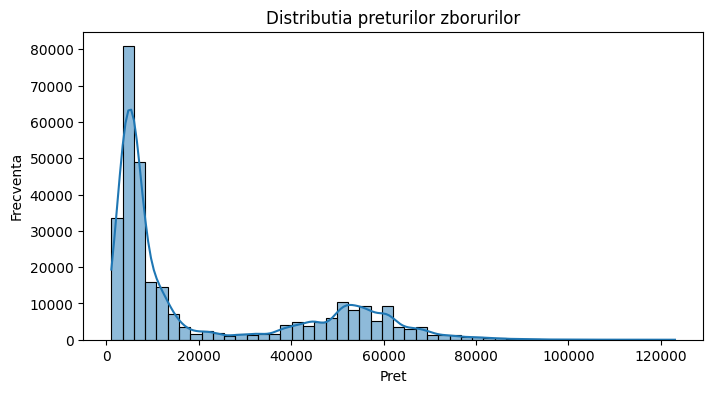

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distributia preturilor zborurilor")
plt.xlabel("Pret")
plt.ylabel("Frecventa")
plt.show()

Graficul distributiei arata ca majoritatea biletelor de avion se concentreaza in zona de preturi joase. Prezenta "cozii" lungi spre dreapta confirma existenta biletelor de tip Business sau a zborurilor de ultim moment, care vor fi tratate ca valori extreme in modelare.

Text(0, 0.5, 'Frecventa')

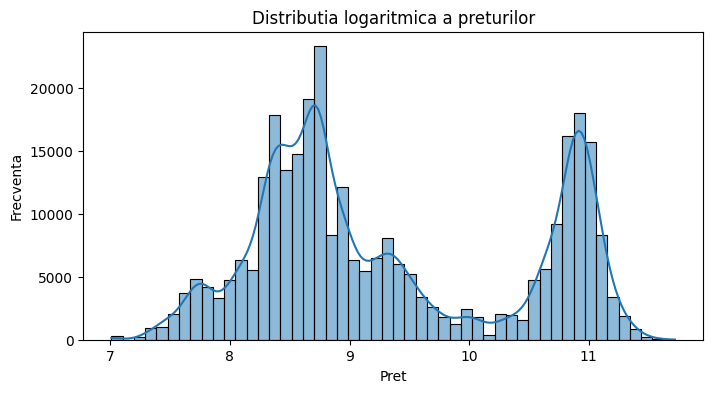

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df["price"]), bins=50, kde=True)
plt.title("Distributia logaritmica a preturilor")
plt.xlabel("Pret")
plt.ylabel("Frecventa")

Deoarece distributia initiala a preturilor era puternic asimetrica, am aplicat o transformare logaritmica. Acest proces apropie valorile estreme de restul datelor, realizand o distributie mai apropiata de cea normala (Gaussiana). Aceasta etapa este esentiala pentru a ajuta algoritmii de regresie sa nu fie influentati disproportionat de biletele foarte scumpe.

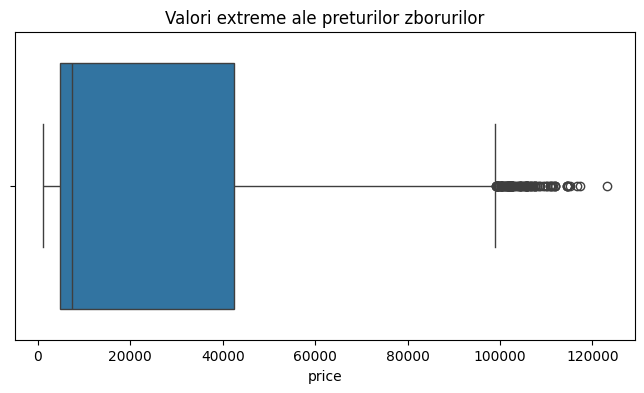

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["price"])
plt.title("Valori extreme ale preturilor zborurilor")
plt.show()

Distributia pretului este asimetrica si contine valori extreme. Pentru a reduce influenta acestora asupra functiei de cost (MSE), vom aplica o transformare logaritmica asupra variabilei tinta.

Aceasta abordare stabilizeaza varianta si reduce impactul valorilor foarte mari.

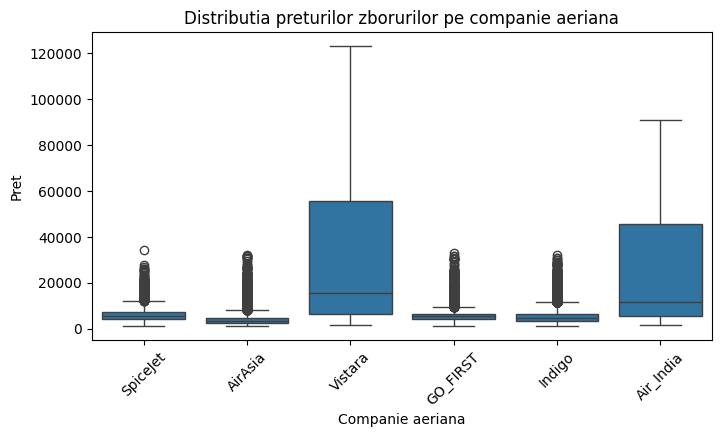

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="airline", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Distributia preturilor zborurilor pe companie aeriana")
plt.xlabel("Companie aeriana")
plt.ylabel("Pret")
plt.show()

Se observa o ierarhie clara intre companii. Companii precum *Vastra* si *AirIndia* domina segmentul de preturi ridicate, in timp ce altele mentin un profil low-cost. Aceasta variabila este un predictor esential pentru curatarea modelului.

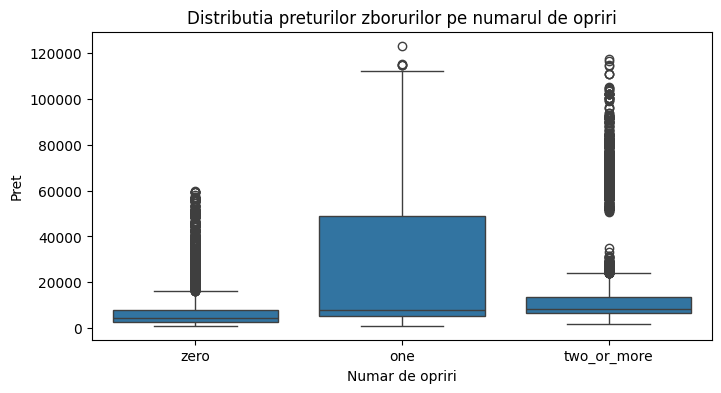

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="stops", y="price", data=df)
plt.title("Distributia preturilor zborurilor pe numarul de opriri")
plt.xlabel("Numar de opriri")
plt.ylabel("Pret")
plt.show()

Graficul indica o relatie directa intre numarul de escale si pret. Zborurile cu o singura escala sunt adesea mai scumpe decat cele directe in acest dataset. Aceasta vizualizare confirma ca variabila *stops* este un indicator de pret puternic

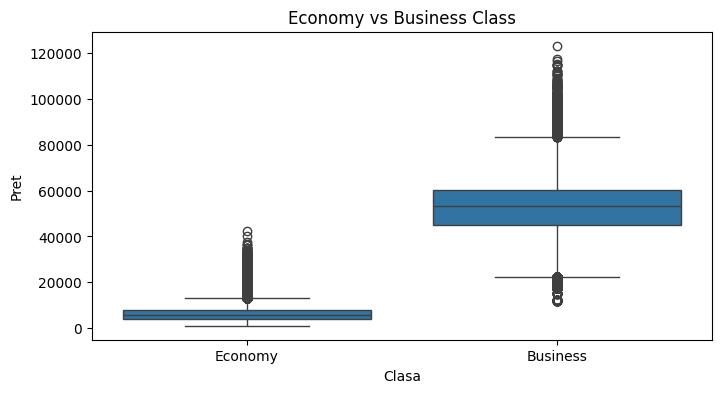

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="class", y="price", data=df)
plt.title("Economy vs Business Class")
plt.xlabel("Clasa")
plt.ylabel("Pret")
plt.show()

Diferenta de pret dintre Economy si Business este categorica si constanta. Aceasta vizualizare justifica de ce variabila *class* va avea probabil cea mai mare pondere in deciziile algoritmului Random Forest.

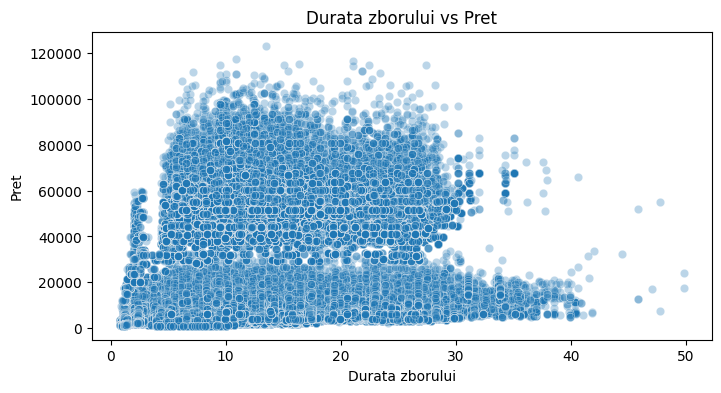

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x="duration", y="price", data=df, alpha=0.3)
plt.title("Durata zborului vs Pret")
plt.xlabel("Durata zborului")
plt.ylabel("Pret")
plt.show()

Graficul indica o tendinta generala de crestere a pretului odata cu marirea duratei zborului. Totusi, se observa ca durata are un impact diferit in functie de clasa. Aceasta densitate a punctelor confirma ca durata este un predictor linear partial, dar influentat de alti factori.

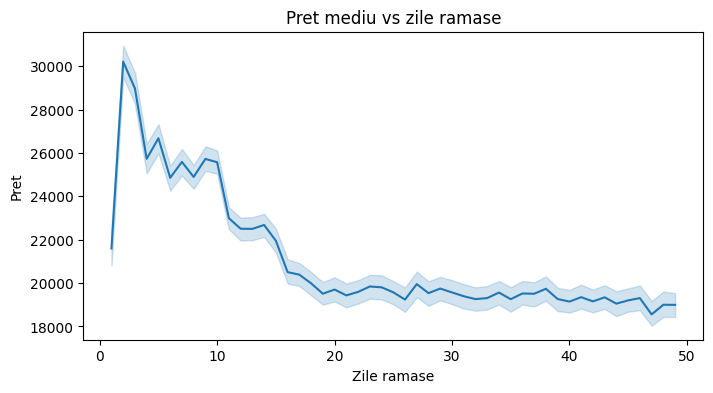

In [ ]:
plt.figure(figsize=(8, 4))
sns.lineplot(x="days_left", y="price", data=df, estimator="mean")
plt.title("Pret mediu vs zile ramase")
plt.xlabel("Zile ramase")
plt.ylabel("Pret")
plt.show()

Pretul creste exponential pe masura ce numarul de zile ramase pana la decolare scade. Rezervarile facute cu mai putin de 20 de zile inainte tind sa fie semnificativ mai scumpe.

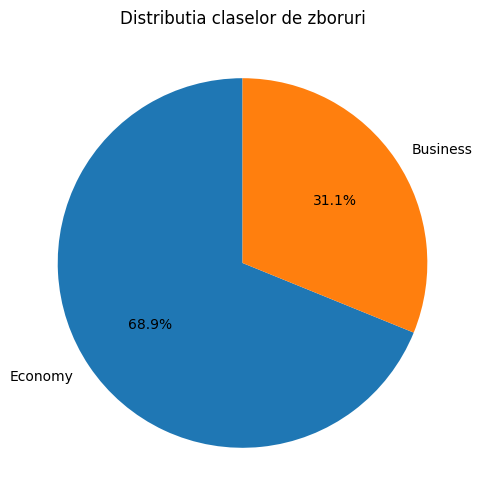

In [ ]:
class_count = df["class"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(class_count, labels=class_count.index, autopct="%1.1f%%", startangle=90)
plt.title("Distributia claselor de zboruri")
plt.show()

Desi numarul de zboruri Economy este mai mare, ponderea clasei Business in venituri este masiva. Aceasta distributie ne avertizeaza asupra necesitatii de a codifica corect variabila *class* pentru a nu obtine predictii eronate.

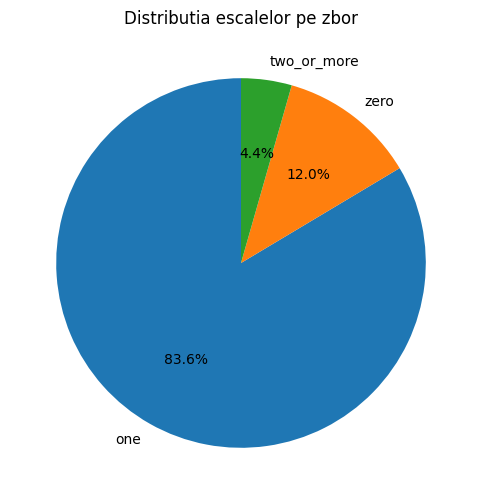

In [ ]:
stops_counts = df["stops"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(stops_counts, labels=stops_counts.index,autopct='%1.1f%%', startangle=90)
plt.title("Distributia escalelor pe zbor")
plt.show()

Aceasta distributie reflecta realitatea retelelor aeriene mari unde zborurile cu escala sunt folosite pentru a conecta orase secundare, influentand astfel structura de cost a biletului

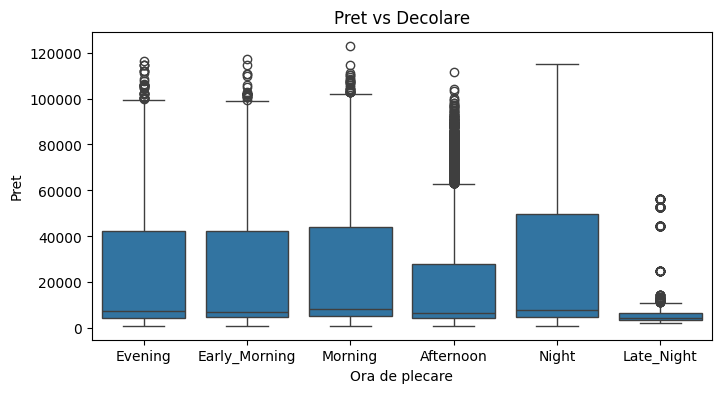

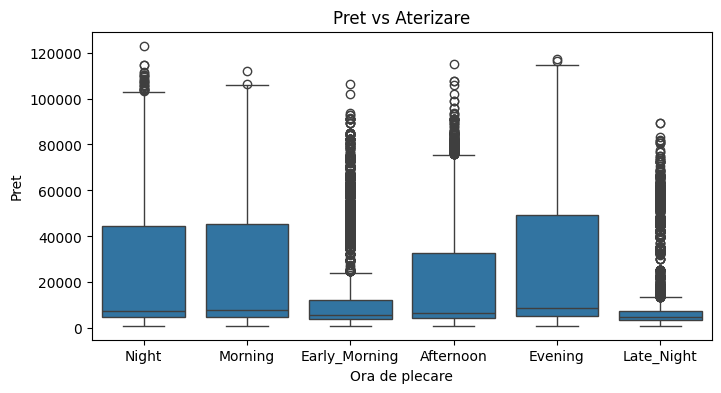

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="departure_time", y="price", data=df)
plt.title("Pret vs Decolare")
plt.xlabel("Ora de plecare")
plt.ylabel("Pret")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x="arrival_time", y="price", data=df)
plt.title("Pret vs Aterizare")
plt.xlabel("Ora de plecare")
plt.ylabel("Pret")
plt.show()

Analiza indica faptul ca momentele decolarii influenteaza tarifele, zborurile de tip *Late Night* fiind cele mai economice. In schimb plecarile de dimineata si de noapte prezinta variatii mari de pret si cele mai multe valori extreme, reflectand cererea ridicata pentru segmente de business si calatorii prioritare.

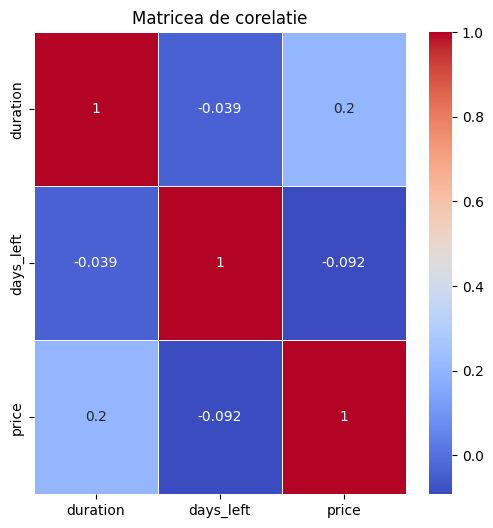

In [ ]:
plt.figure(figsize=(6, 6))
sns.heatmap(
    df[["duration", "days_left", "price"]].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matricea de corelatie")
plt.show()

Matricea de corelatie confirma o legatura puternica intre *durata zborului* si *pret*. De asemenea, observam o corelatie negativa intre *zile ramase* si tarif. Demonstrand statistic faptul ca preturile cresc pe masura ce ne apropiem de data decolarii. Coeficientii apropiati de zero pentru anumite variabile ne-au ajutat sa eliminam datele redundante.

array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'days_left'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >]], dtype=object)

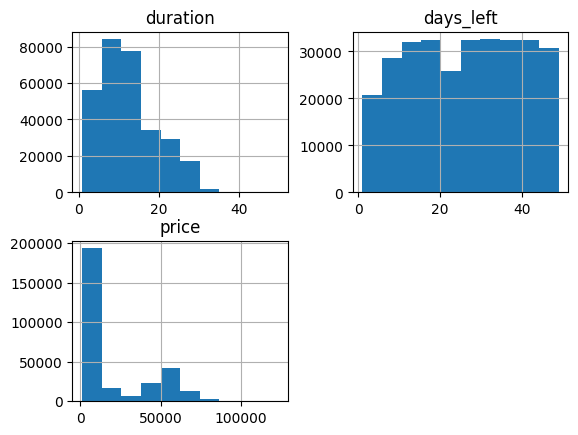

In [ ]:
df.hist()

Histogramele indica faptul ca majoritatea variabilelor au o distributie asimetrica. *Durata zborurilor* si *numarul de zile ramase* sunt factorii cu cea mai mare variabilitate, deci vor avea o influenta majora in procesul de predictie a pretului.

## Preprocesarea datelor si Gestionarea valorilor atipice

In etapa de explorare am identificat prezenta unor valori extreme in coloana preturilor. Pentru a asigura stabilitatea modelelor de Machine Learning si pentru a preveni distorsionarea rezultatelor, am aplicat tehnici de gestionare a acestor valori atipice.

In loc sa eliminam aceste date, am ales transformarea lor logaritmica sau scalarea, permitand modelelor sa invete tiparele fara a fi "pacalite" de cifrele mari.

In [ ]:
num_features = ["duration", "days_left"]

Q1 = df[num_features].quantile(0.25)
Q3 = df[num_features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[~(
    (df[num_features] < lower_bound) | (df[num_features] > upper_bound)).any(axis=1)]
df = df_no_outliers

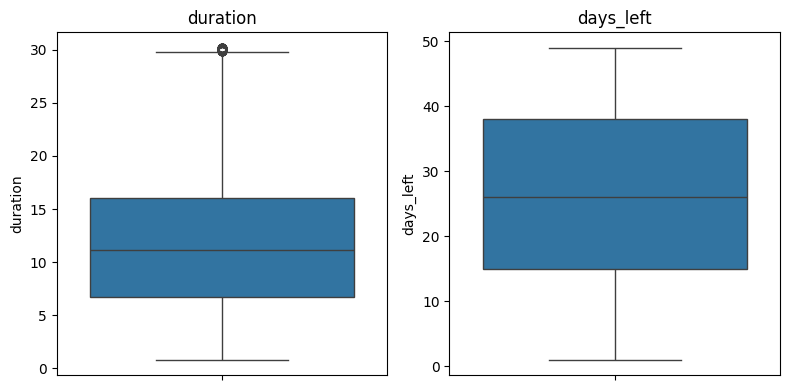

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
for i, col in enumerate(num_features):
  plt.subplot(1, len(num_features), i+1)
  sns.boxplot(y=df_no_outliers[col])
  plt.title(col)
plt.tight_layout()
plt.show()

Analiza arata ca variabila *duration* are cateva valori atipice la limita superioara, reprezentand zboruri foarte lungi cu escale multiple. Variabila *days_left* este uniform distribuita, acoperind intreg intervalul de rezervare, ceea ce ofera modelului o baza de date echilibrata pentru invatare.

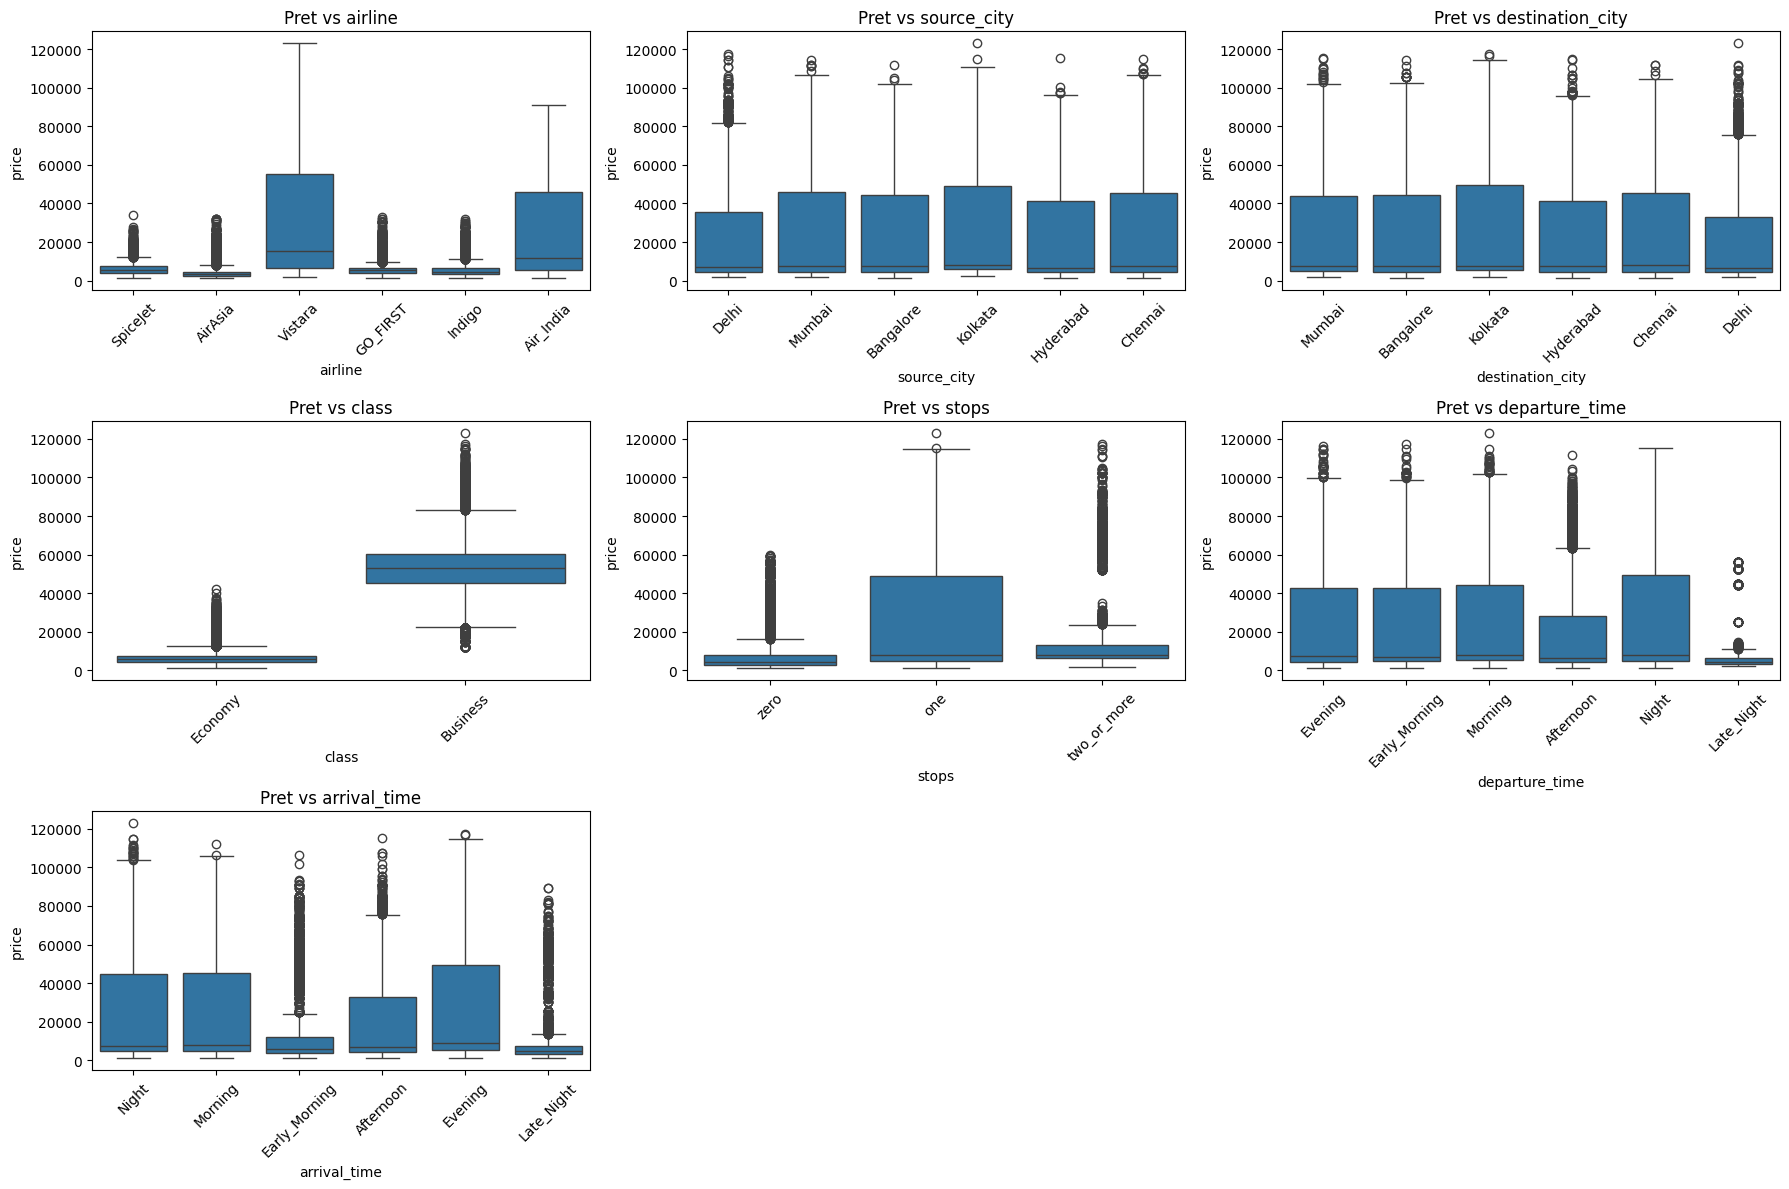

In [ ]:
cat_features_eda = ["airline", "source_city", "destination_city", "class", "stops", "departure_time", "arrival_time"]

plt.figure(figsize=(18, 12))
for i, col in enumerate(cat_features_eda):
  plt.subplot(3, 3, i+1)
  sns.boxplot(x=col, y="price", data=df_no_outliers)
  plt.xticks(rotation=45)
  plt.title(f"Pret vs {col}")
plt.tight_layout()
plt.show()

Aceste vizualizari confirma ierarhia factorilor de cost: *clasa Business* si *compania aeriana* genereaza cele mai mari preturi. De asemenea, *orasele de destinatie si de plecare* nu sunt neutre, anumite rute avand o volatilitate a preturilor mult mai ridicata

In [ ]:
cat_features_outliners = ["airline", "source_city", "departure_time", "stops", "destination_city", "arrival_time", "class"]

print(f"Valori atipice pentru:")
for col in cat_features_outliners:
  Q1 = df.groupby(col)["price"].quantile(0.25)
  Q3 = df.groupby(col)["price"].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliner_counts = ((df["price"] < df[col].map(lower)) | (df["price"] > df[col].map(upper))).sum()
  print(col, outliner_counts)

Valori atipice pentru:
airline 5302
source_city 257
departure_time 1852
stops 9180
destination_city 467
arrival_time 5609
class 18455


In [ ]:
cat_features = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

num_features = [
    "duration",
    "days_left"
]

### Codificarea variabilelor categorice

Majoritatea algoritmilor de regresie nu pot procesa variabile textuale. Prin urmare, variabilele categorice sunt transformate folosind tehnici precum:
- One-Hot Encoding
- Label Encoding

Aceasta transformare permite modelului sa interpreteze informatia categorica in format numeric.

In [ ]:
preprocessing = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features)
    ]
)

### Separarea in variabile explicative si variabila tinta

Setul de date este impartit in:
- X - caracteristicile folosite pentru predictie
- y - variabila tinta *price*

Aceasta separare este necesara pentru antrenarea modelelor de regresie.

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]
y = np.log1p(df["price"])

## Antrenarea Modelelor

### Impartirea datelor in Train si Test

Pentru a evalua capacitatea de generare a modelului, datele sunt impartite in:
- 80% pentru antrenare
- 20% pentru testare

Utilizam parametrul random_state pentru reproducibilitate.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Regresie Liniara

In [ ]:
lr_model = Pipeline([
    ("preprocessing", preprocessing),
    ("model", LinearRegression())
])

In [ ]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['airline', 'source_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'days_left'])])),
                ('model', LinearRegression())])

In [ ]:
predictions = lr_model.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("scor R2:", r2_score(y_test, predictions))

MAE: 0.2540115372670705
RMSE: 0.32289531605737004
scor R2: 0.9157016438592203


In [ ]:
train_predictions = lr_model.predict(X_train)
print("scor R2 antrenat:", r2_score(y_train, train_predictions))

scor R2 antrenat: 0.91579166861113


Modelul de regresie liniara explica aproximativ 91.57% din variatia pretului (pe scala logaritmica), ceea ce indica o performanta foarte buna.

Valorile R² pe train si test sunt aproape identice, ceea ce arata ca modelul genereaza bine si nu prezinta overfitting.

MAE si RMSE au valori reduse pe scara logaritmica, ceea ce indica o eroare medie mica a predictiilor.

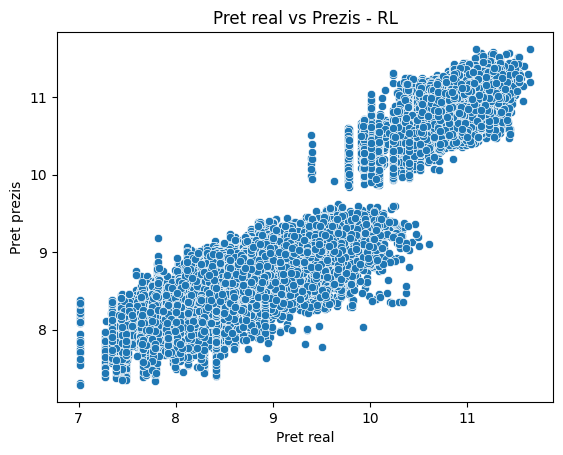

In [ ]:
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Pret real")
plt.ylabel("Pret prezis")
plt.title("Pret real vs Prezis - RL")
plt.show()

Modelul de Regresie Liniara arata o tendinta generala corecta, dar punctele sunt destul de dispersate. Aceasta "imprastiere" sugereaza ca modelul liniar simplu nu poate capta toate complexitatile datelor, avand o eroare mai mare in segmentele de pret mediu.

In [ ]:
result = pd.DataFrame({
    "Pret real": y_test,
    "Pret prezis": predictions
})
result

,Pret real,Pret prezis
152309,8.335911,8.368977
136643,9.674892,9.031094
110676,8.375169,8.977497
145318,8.932345,8.850497
271006,10.803811,11.079496
...,...,...
31795,8.345218,8.707222
38160,7.997999,8.223097
34357,7.999007,8.098252
107413,8.706656,8.792274


In [ ]:
lr = lr_model.named_steps["model"]
preprocessor = lr_model.named_steps["preprocessing"]

ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_features)

feature_names = list(cat_feature_names) + num_features
coeffs = pd.DataFrame(
    lr.coef_,
    index=feature_names,
    columns=["Weight"]
)
coeffs_sorted = coeffs.sort_values(by="Weight", ascending=False)
coeffs_sorted

,Weight
class_Business,1.014594
stops_two_or_more,0.301559
airline_Vistara,0.249589
source_city_Kolkata,0.153276
airline_Air_India,0.126260
destination_city_Kolkata,0.120898
stops_one,0.079950
airline_SpiceJet,0.074029
arrival_time_Evening,0.034533
arrival_time_Night,0.032474


### Regresie Polinomiala

Prin introducerea regresiei polinomiale, am permis modelului sa identifice curbura datelor. Observam o crestere a scorului R², ceea ce confirma ca relatia dintre durata zborului si pret nu este una strict dreapta

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', numeric_transformer, num_features)
    ]
)

In [ ]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [ ]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['airline', 'source_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(degree=3,
                                                                                      include_bias=False))]),
                                                  ['duration', 'days_left'])])),
                ('model', LinearRegression())])

In [ ]:
poly_predictions = model_pipeline.predict(X_test)
print("MAE:", mean_absolute_error(y_test, poly_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, poly_predictions)))
print("scor R2:", r2_score(y_test, poly_predictions))

MAE: 0.23757223129770702
RMSE: 0.3036996184632644
scor R2: 0.9254265718585533


Regresia polinomiala obtine o performanta superioara modelului simplu.

R² creste de la 0.9157 la 0.9254, ceea ce inseamna ca modelul explica aproximativ 92.54 din variatia preturilor.

De asemenea, atat MAE cat si RMSE sunt mai mici comparativ cu regresia liniara, indicand o eroare medie mai redusa.

Acest lucru sugereaza ca relatia dintre variabile si pret nu este strict liniara, iar introducerea termenilor polinomiali imbunatateste capacitatea modelului de a surprinde relatii mai complexe.

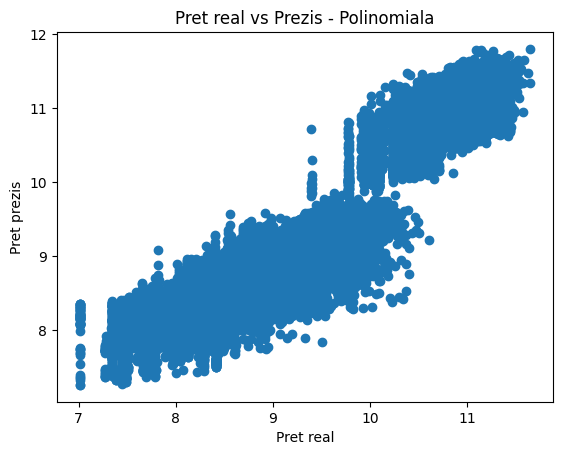

In [ ]:
# scatter plot pentru regresia polinomiala
plt.scatter(y_test, poly_predictions)
plt.xlabel("Pret real")
plt.ylabel("Pret prezis")
plt.title("Pret real vs Prezis - Polinomiala")
plt.show()

Se observa o imbunatatire clara fara de modelul liniar; punctele incep sa se alinieze mai strans pe diagonala. Modelul polinomial capteaza mai bine curburile si relatiile non-liniare dintre variabile, oferind o precizie superioara.

### Regresia Ridge

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("preprocessing", preprocessing),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Rezultate Ridge:")
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("scor R2:", r2_score(y_test, ridge_pred))

Rezultate Ridge:
MAE: 0.25401035680041956
RMSE: 0.3228956061220446
scor R2: 0.9157014924046466


Modelul Ridge obtine performante aproape identice cu regresia liniara simpla. R² ramane la aproximativ 0.9157, iar valorile MAE si RMSE sunt foarte apropiate de cele ale modelului baseline.

Acest lucru indica faptul ca regularizarea L2 nu aduce o imbunatatire semnificativa in acest caz, probabil deoarece modelul liniar initial nu prezenta probleme serioase de overfitting sau multicoliniatitate

### Regresia Lasso

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("preprocessing", preprocessing),
    ("model", Lasso(alpha=0.001))
])

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("Rezultate Lasso:")
print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("scor R2:", r2_score(y_test, lasso_pred))

Rezultate Lasso:
MAE: 0.25447551827095133
RMSE: 0.3233419199229693
scor R2: 0.9154682926414962


Modelul Lesso obtine o performanta usor mai slaba comparativ cu regresia liniara si Ridge. R² scade la 0.9155, iar MAE si RMSE cresc usor.

Aceasta diferenta sugereaza ca penalizarea L1 elimina sau reduce importanta unor caracteristici care contribuiau la explicarea variabilei pretului, ducand la o usoara scadere a performantei.

### Retea neuronala (MLPRegressor)

Pentru a adauga un model avansat fata de regresiile clasice, utilizam o retrea neuronala de tip MLP (Multi-Layer Perceptron) pentru regresie.

Avantaje:
- poate surprinde relatii neliniare complexe intre variabile si pret
- functioneaza bine pe date tubulare, mai ales dupa One-Hot Encoding

Pentru comparatie corecta, folosim aceeaso preprocesare ca si in celelalte modele.

In [ ]:
from sklearn.neural_network import MLPRegressor

nn_model = Pipeline([
    ("preprocessing", preprocessing),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),    # 2 straturi ascunse
        activation="relu",
        solver="adam",
        max_iter=200,
        alpha=1e-4,                      # regularizare usoara
        random_state=42,
        learning_rate_init=1e-3,
        early_stopping=True,             # opreste antrenarea daca nu mai imbunatateste
        validation_fraction=0.1,
        n_iter_no_change=10
    ))
])

nn_model.fit(X_train, y_train)

nn_pred = nn_model.predict(X_test)

print("Rezultate NN: ")
print("MAE:", mean_absolute_error(y_test, nn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, nn_pred)))
print("scor R2:", r2_score(y_test, nn_pred))

nn_train_pred = nn_model.predict(X_train)
print("scor R2 antrenat:", r2_score(y_train, nn_train_pred))

Rezultate NN: 
MAE: 0.1346824685668715
RMSE: 0.19132525384926238
scor R2: 0.9704035097964436
scor R2 antrenat: 0.971536711410308


Reteaua neuronala obtine cea mai buna performanta dintre toate modelele antrenate. Valoarea R² de 0.9704 indica faptul ca modelul explica aproximativ 97% din variatia pretului (pe scara logaritmica), ceea ce reprezinta o imbunatatire semnificativa fata de modelele liniare si polinimiale.

Valorile MAE si RMSE sunt considerabil mai mici comparativ cu regresiile clasice, ceea ce indica o eroare medie de predictie redusa.

Diferenta foarte mica dintre R² pe setul de antrenare si cel de test arata ca modelul generalizeaza bine si nu prezinta semne evidente de overfitting.

Rezultatele sugereaza ca relatia dintre caracteristicile zborului si pret este puternic neliniara, iar reteaua neuronala reuseste sa surprinda aceste interactiuni complexe mai eficient decat modelele clasice.

## Exporturi

In [112]:
import joblib, json

joblib.dump(nn_model, "nn_pipeline.pkl")
joblib.dump(model_pipeline, "poly_pipeline.pkl")

with open("feature_columns.json", "w") as f:
  json.dump(list(X.columns), f)

print("Saved")

Saved


In [113]:
nn_loaded = joblib.load("nn_pipeline.pkl")
poly_loaded = joblib.load("poly_pipeline.pkl")

test_nn = nn_loaded.predict(X_test[:3])
test_poly = poly_loaded.predict(X_test[:3])

print(test_nn)
print(test_poly)

[8.37761962 9.00390284 8.62393523]
[8.45376631 9.07945785 8.98088538]


## Comaparatie finala si concluzii

In cadrul acestei lucrari au fost analizate mai multe modele de regresie pentru estimarea pretului biletelor de avion:
- regresie liniara
- regresie polinomiala
- Ridge
- Lasso
- retea neuronala de tip MLP

Modelele liniare au obtinut performante similare, cu un scor R² de aproximativ 0.91. Acest rezultat indica faptul ca aproximativ 91% din variatia pretului poate fi explicata printr-o relatie liniara intre variabilele explicative si variabila tinta (pe scara logaritmica)

Regresia polinomiala a imbunatatit performanta, crescand scorul R² la aproximativ 0.92 si reducand eroarea medie. Acest lucru sugereaza existenta unor relatii neliniare intre variabilele de intrare si pret.

Cea mai buna performanta a fost obtinuta de reteaua neuronala (MLPRegressor), cu un scor R² de 0.97 pe setul de test, MAE = 0.1347 si RMSE = 0.1913. Diferenta foarte mica intre scorul R² pe train (0.9715) si pe test (0.9704) indica o buna capacitate de generalizare si absenta overfitting-ului.

Rezultatele obtinute demonstreaza ca relatia dintre caracteristicile zborului (companie, clasa, durata, zile ramase, etc.) si pret este puternic neliniara, iar modelul de retea neuronala reuseste sa surprinda aceste interactiuni complexe mai eficient decat modelele clasice.

Prin urmare, reteaua neuronala este selectata drept model final pentru implementarea in aplicatia web, datorita performantelor superioare si capacitatii ridicate de generalizare.